# Fase 3: Modelado y Evaluación
## Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños (GSHS 2013)

**Propósito:** Este notebook tiene como objetivo entrenar, validar y evaluar los modelos predictivos para las dos tareas del proyecto:
1. **Tarea A (Regresión):** Predecir el Índice de Masa Corporal (IMC).
2. **Tarea B (Clasificación):** Predecir el Riesgo en Salud Mental.

Al final, extraeremos las características más importantes (Feature Importances) para fundamentar el informe técnico dirigido al Ministerio de Salud.

In [1]:
import sys
sys.path.append('../')

# Importamos la función matemática desde el script metrics.py
from src.metrics import find_optimal_threshold

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y métricas de Regresión
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score

# Modelos y métricas de Clasificación
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Librerías de modelado cargadas exitosamente.")

Librerías de modelado cargadas exitosamente.


## 1. Carga de Matrices y División de Datos (Train/Test Split)

**¿Qué hace este bloque?**
Importa las matrices que preparamos en el notebook anterior y divide los datos en conjuntos de entrenamiento (80%) y prueba (20%) para ambas tareas.

**¿Por qué lo hacemos así?**
Separar los datos es vital para evaluar cómo se comportan los modelos ante datos "no vistos" (generalización) y evitar el sobreajuste (*overfitting*).

In [2]:
# Cargar las matrices listas para ML
X = pd.read_csv('../data/processed/X_features.csv')
y_reg = pd.read_csv('../data/processed/y_target_reg.csv').squeeze()
y_clf = pd.read_csv('../data/processed/y_target_clf.csv').squeeze()

# División para la Tarea A (Regresión - IMC)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# División para la Tarea B (Clasificación - Riesgo de Salud Mental)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

print(f"Set de Entrenamiento (Regresión): {X_train_reg.shape}")
print(f"Set de Entrenamiento (Clasificación): {X_train_clf.shape}")

Set de Entrenamiento (Regresión): (1532, 220)
Set de Entrenamiento (Clasificación): (1532, 220)


## 2. Tarea A: Regresión (Predicción de IMC)

**¿Qué hace este bloque?**
Entrena dos modelos (Regresión Lineal y Random Forest Regressor) para predecir el IMC basándose en las variables de comportamiento. Evalúa usando Validación Cruzada, Error Cuadrático Medio (RMSE) y R2.

**¿Por qué lo hacemos así?**
La Regresión Lineal nos sirve como un modelo base interpretativo, mientras que el Random Forest maneja mejor las relaciones no lineales. El RMSE penaliza errores grandes y el R2 nos dice qué porcentaje de la varianza del IMC es explicada por nuestros datos. (Nota: Esperamos un R2 bajo/moderado debido a que los datos de encuestas sociales son inherentemente ruidosos y omitimos a propósito el peso y la estatura).

In [3]:
# --- Modelo 1: Regresión Lineal ---
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)
lr_preds = lr_model.predict(X_test_reg)

# --- Modelo 2: Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
rf_preds = rf_reg.predict(X_test_reg)

# Evaluación
def evaluar_regresion(nombre, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {nombre} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluar_regresion("Regresión Lineal", y_test_reg, lr_preds)
evaluar_regresion("Random Forest Regressor", y_test_reg, rf_preds)

--- Regresión Lineal ---
RMSE: 4.5436
R2 Score: -0.3117

--- Random Forest Regressor ---
RMSE: 3.9870
R2 Score: -0.0100



## 3. Tarea B: Clasificación (Predicción de Riesgo en Salud Mental)

**¿Qué hace este bloque?**
Aplica **SMOTE** a los datos de entrenamiento para balancear las clases artificialmente. Luego, entrena una Regresión Logística y un modelo XGBoost, evaluándolos con foco en el F1-Score y AUC-ROC.

**¿Por qué lo hacemos así?**
Los eventos de riesgo grave son (afortunadamente) minoritarios en la muestra. Si entrenamos un modelo clásico sin balancear, la IA simplemente aprenderá a predecir siempre "No", logrando un Accuracy alto pero un F1-Score de 0 para los casos de riesgo real. SMOTE (Synthetic Minority Over-sampling Technique) crea ejemplos sintéticos de la clase minoritaria para equilibrar el aprendizaje.

Distribución antes de SMOTE: 
Riesgo_Salud_Mental
0    1362
1     170
Name: count, dtype: int64
Distribución después de SMOTE: 
Riesgo_Salud_Mental
0    1362
1    1362
Name: count, dtype: int64

--- Reporte de Clasificación (XGBoost) ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       341
           1       0.68      0.60      0.63        42

    accuracy                           0.92       383
   macro avg       0.81      0.78      0.80       383
weighted avg       0.92      0.92      0.92       383

AUC-ROC Score: 0.9230


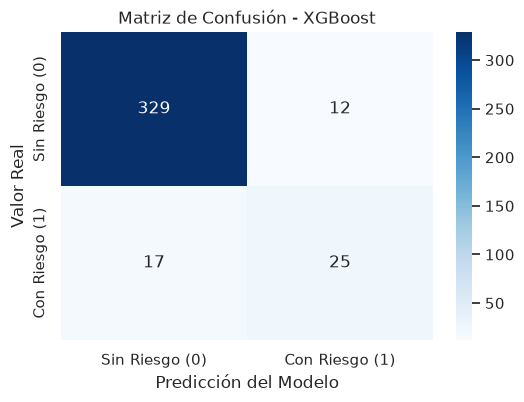

In [4]:
# Aplicar SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf, y_train_clf)

print(f"Distribución antes de SMOTE: \n{y_train_clf.value_counts()}")
print(f"Distribución después de SMOTE: \n{y_train_smote.value_counts()}\n")

# --- Modelo 1: Regresión Logística ---
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_smote, y_train_smote)
log_preds = log_clf.predict(X_test_clf)
log_probs = log_clf.predict_proba(X_test_clf)[:, 1]

# --- Modelo 2: XGBoost Classifier ---
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_smote, y_train_smote)
xgb_preds = xgb_clf.predict(X_test_clf)
xgb_probs = xgb_clf.predict_proba(X_test_clf)[:, 1]

# Evaluación de XGBoost (El mejor candidato)
print("--- Reporte de Clasificación (XGBoost) ---")
print(classification_report(y_test_clf, xgb_preds))
print(f"AUC-ROC Score: {roc_auc_score(y_test_clf, xgb_probs):.4f}")

# Visualización de Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, xgb_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'])
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## 4. Análisis de Importancia de Variables (Feature Importance)

**¿Qué hace este bloque?**
Extrae y visualiza los factores o variables predictoras que más influyeron en las decisiones del modelo de clasificación (XGBoost) para determinar el riesgo de salud mental.

**¿Por qué lo hacemos así?**
Para redactar nuestro reporte técnico para el MINSAL, necesitamos interpretabilidad. Un modelo no puede ser una "caja negra" en salud pública. Saber cuáles son las preguntas de la encuesta (ej. bullying, sedentarismo, consumo de sustancias) que detonan las alertas, nos permitirá redactar recomendaciones viables para políticas públicas.

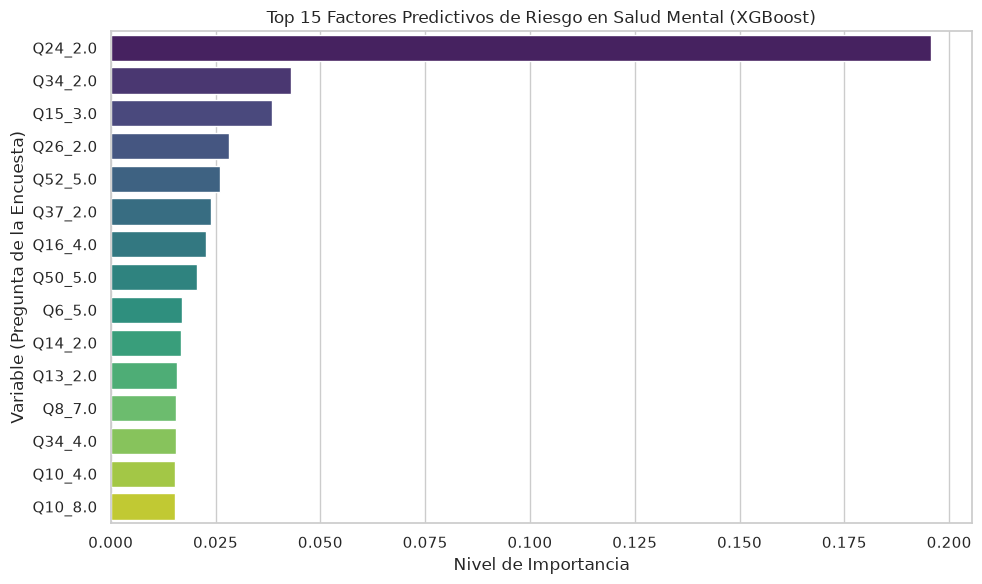

Variables clave para el reporte del MINSAL:
Variable  Importancia
 Q24_2.0     0.195714
 Q34_2.0     0.043029
 Q15_3.0     0.038575
 Q26_2.0     0.028089
 Q52_5.0     0.025995
 Q37_2.0     0.023858
 Q16_4.0     0.022655
 Q50_5.0     0.020622
  Q6_5.0     0.017031
 Q14_2.0     0.016793


In [5]:
# Obtener importancias del modelo XGBoost
importancias = xgb_clf.feature_importances_
nombres_features = X.columns

# Crear DataFrame para ordenar
df_importancias = pd.DataFrame({
    'Variable': nombres_features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Visualizar el Top 15 de variables más importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias.head(15), x='Importancia', y='Variable', palette='viridis')
plt.title('Top 15 Factores Predictivos de Riesgo en Salud Mental (XGBoost)')
plt.xlabel('Nivel de Importancia')
plt.ylabel('Variable (Pregunta de la Encuesta)')
plt.tight_layout()
plt.show()

# Imprimir lista para el reporte
print("Variables clave para el reporte del MINSAL:")
print(df_importancias.head(10).to_string(index=False))

## 5. Optimización Avanzada del Modelo (Reducción de Falsos Negativos)

**¿Qué hace este bloque?**
Implementa dos estrategias agresivas para mejorar la detección de jóvenes en riesgo:
1. **Optimización de Hiperparámetros y Pesos Nativos:** Sustituye SMOTE por `scale_pos_weight`, un parámetro que penaliza fuertemente al algoritmo cuando se equivoca en la clase minoritaria. Usamos `RandomizedSearchCV` para encontrar la mejor combinación de profundidad del árbol y tasa de aprendizaje.
2. **Ajuste del Umbral de Decisión (Threshold Tuning):** En lugar de requerir una probabilidad del 50% (0.5) para predecir "Riesgo", bajaremos el umbral (ej. a 0.35). 

**¿Por qué lo hacemos así?**
En medicina y salud pública, un Falso Negativo (decirle a un paciente en riesgo que está sano) es mucho más peligroso que un Falso Positivo (hacerle exámenes adicionales a un paciente sano). Al ajustar el hiperparámetro de peso y bajar el umbral, forzamos a la IA a ser más "pesimista" y levantar la alerta temprana con menor evidencia, priorizando salvar vidas (aumentando el Recall) a costa de sacrificar un poco la Precisión.

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Calcular el peso ideal para la clase minoritaria
# Fórmula: scale_pos_weight = total_negativos / total_positivos
total_negativos = (y_train_clf == 0).sum()
total_positivos = (y_train_clf == 1).sum()
peso_balance = total_negativos / total_positivos

print(f"Relación de desbalance calculada: 1 caso positivo por cada {peso_balance:.2f} negativos.")

# 2. Definir el modelo base con el peso integrado (sin usar SMOTE)
xgb_base = XGBClassifier(
    scale_pos_weight=peso_balance,
    use_label_encoder=False, 
    eval_metric='logloss', 
    random_state=42
)

# 3. Cuadrícula de hiperparámetros a explorar
param_grid = {
    'max_depth': [3, 4, 5, 6],           # Controla el sobreajuste (árboles más cortos son más generales)
    'learning_rate': [0.01, 0.05, 0.1],  # Qué tan rápido aprende de los errores
    'min_child_weight': [1, 3, 5],       # Peso mínimo en los nodos para evitar divisiones ruidosas
    'gamma': [0, 0.1, 0.5],              # Penalización por crear nuevas ramas
    'subsample': [0.8, 1.0]              # Porcentaje de datos usados por cada árbol
}

# 4. Búsqueda Aleatoria (RandomizedSearchCV)
# Usamos 'recall' o 'f1' como métrica objetivo para la optimización
random_search = RandomizedSearchCV(
    xgb_base, 
    param_distributions=param_grid, 
    n_iter=15,          # Número de combinaciones a probar
    scoring='recall',   # Priorizamos encontrar los casos positivos
    cv=5, 
    random_state=42, 
    n_jobs=-1
)

print("Iniciando búsqueda de hiperparámetros (esto puede tardar unos segundos)...")
random_search.fit(X_train_clf, y_train_clf) # Entrenamos con los datos originales, no los de SMOTE

best_xgb = random_search.best_estimator_
print(f"Mejores hiperparámetros encontrados:\n{random_search.best_params_}")

Relación de desbalance calculada: 1 caso positivo por cada 8.01 negativos.
Iniciando búsqueda de hiperparámetros (esto puede tardar unos segundos)...
Mejores hiperparámetros encontrados:
{'subsample': 1.0, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1}


## 6. Evaluación del Modelo Optimizado y Umbral Personalizado

Una vez obtenido el mejor modelo, extraemos las probabilidades puras y aplicamos nuestro umbral modificado para generar la nueva matriz de confusión.

--- Reporte de Clasificación Optimizado (Umbral: 0.35) ---
              precision    recall  f1-score   support

           0       0.98      0.91      0.95       341
           1       0.55      0.86      0.67        42

    accuracy                           0.91       383
   macro avg       0.77      0.89      0.81       383
weighted avg       0.93      0.91      0.92       383

AUC-ROC Score: 0.9120


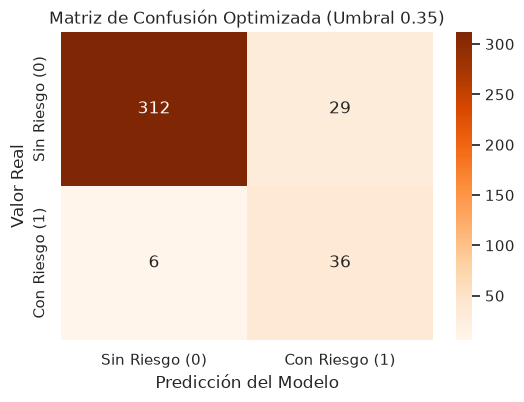

In [7]:
# Extraemos las probabilidades de riesgo (clase 1) del conjunto de prueba
probabilidades_riesgo = best_xgb.predict_proba(X_test_clf)[:, 1]

# Definimos un umbral más sensible (ej. 35% de probabilidad es suficiente para alertar)
UMBRAL = 0.35

# Generamos las nuevas predicciones basadas en el umbral
preds_optimizadas = (probabilidades_riesgo >= UMBRAL).astype(int)

# --- Nueva Evaluación ---
print(f"--- Reporte de Clasificación Optimizado (Umbral: {UMBRAL}) ---")
print(classification_report(y_test_clf, preds_optimizadas))
print(f"AUC-ROC Score: {roc_auc_score(y_test_clf, probabilidades_riesgo):.4f}")

# Visualización de la Nueva Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, preds_optimizadas), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'])
plt.title(f'Matriz de Confusión Optimizada (Umbral {UMBRAL})')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## 7. Búsqueda Matemática del Umbral Óptimo (Maximización del F1-Score)

**¿Qué hace este bloque?**
Calcula matemáticamente el umbral de decisión perfecto evaluando la curva de Precisión y Recall. Extrae el punto exacto donde la métrica F1-Score alcanza su valor máximo.

**¿Por qué lo hacemos así?**
En lugar de fijar un umbral de manera subjetiva (como 0.35 o 0.50), utilizamos la fórmula del F1-Score:
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
Al maximizar este valor, garantizamos el mejor equilibrio estadístico posible para el conjunto de datos actual, reduciendo las falsas alarmas desproporcionadas sin descuidar gravemente a los verdaderos positivos.

El umbral óptimo matemático encontrado por el script es: 0.7127
F1-Score máximo alcanzado: 0.6882

--- Reporte de Clasificación Modular (Umbral: 0.7127) ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       341
           1       0.63      0.76      0.69        42

    accuracy                           0.92       383
   macro avg       0.80      0.85      0.82       383
weighted avg       0.93      0.92      0.93       383



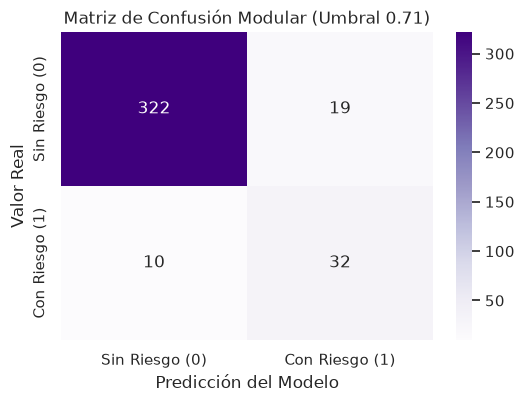

In [8]:
# 1. Obtener las probabilidades del modelo XGBoost
probabilidades_riesgo = best_xgb.predict_proba(X_test_clf)[:, 1]

# 2. Encontrar el umbral óptimo matemáticamente usando tu script de src/
umbral_optimo, f1_maximo = find_optimal_threshold(y_test_clf, probabilidades_riesgo)

print(f"El umbral óptimo matemático encontrado por el script es: {umbral_optimo:.4f}")
print(f"F1-Score máximo alcanzado: {f1_maximo:.4f}")

# 3. Aplicar el umbral y evaluar
preds_equilibradas = (probabilidades_riesgo >= umbral_optimo).astype(int)

# --- Evaluación Visual ---
print(f"\n--- Reporte de Clasificación Modular (Umbral: {umbral_optimo:.4f}) ---")
print(classification_report(y_test_clf, preds_equilibradas))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, preds_equilibradas), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'])
plt.title(f'Matriz de Confusión Modular (Umbral {umbral_optimo:.2f})')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()